<h4>Exploration of Public Comment data</h4>

Public comment periods are a time in a government meeting where the public can generally make remarks on any topic of their choice. Some cities put constraints on this time (like that speakers only speak for 3/5 minutes) but generally people can talk about whatever is on their mind. Public comment data thus provides a window into public opinion on the local level (although, we know that people who speak at these meetings are typically not representative of the general population).

--------------------------------------------------------------------------------

Today we are going to look at a lot of comments in Seattle, Washington and Ann Arbor, MI as well as some comments in other cities to learn about what the public thinks about two important issues to municipal politics: crime and housing.

Today we'll look at:

1. Where is public comment (PC) participation more active (by city / year)?
2. How often do PC remarks mention housing or crime?
3. What stance do people take on these issues?
4. How does the stance of the mayor align with the stance of the public?


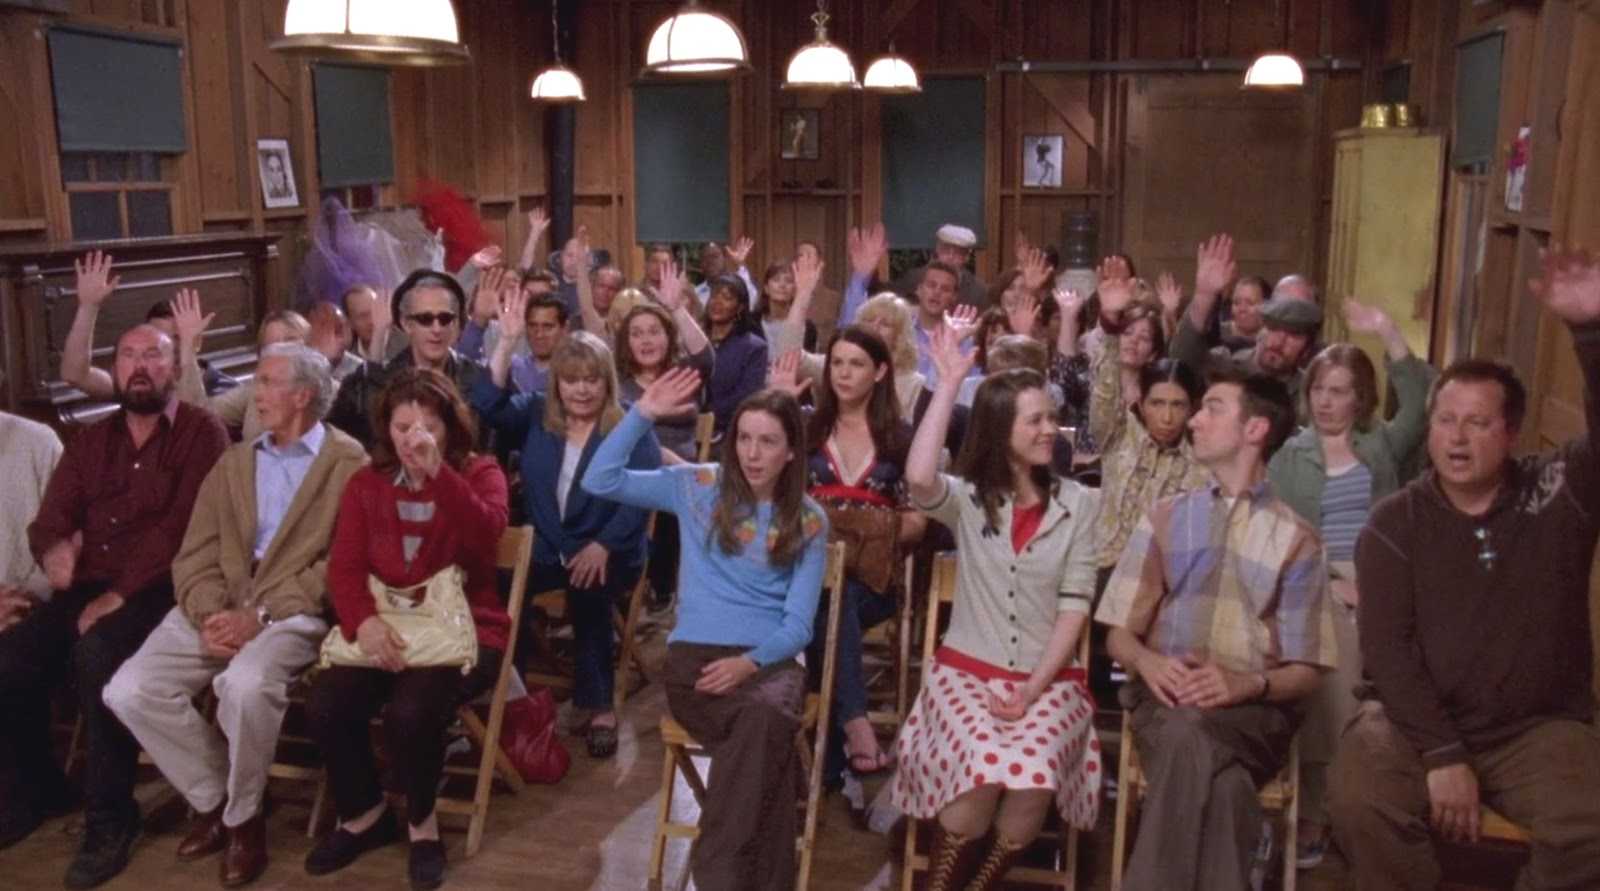

<h4>Let's get started by exploring the data</h4>

We've put together public comments from 19 cities across the US:



First, we're going to take a look at how many public comments occur in the meetings in each city. But before that, let's get our notebook set up.

Colab checklist

1. Download the [utterances](https://drive.google.com/file/d/1yAlbrP7QmjhL6-uYedt7o12fBCYhbw5a/view?usp=sharing) dataset and upload it here (You can access all of the data broken out by city and year at this  ([Drive link](https://drive.google.com/file/d/1V6GojJ-dUCmdPSNmXh7sc5kOxF1jND0I/view?usp=sharing))).
You can also access all of the data we'll use today here: [zip file](https://drive.google.com/file/d/1RuXAnEGRcWr_-vgvR4Q21VQMrjKqe0da/view?usp=sharing)

2. Run the setup cells below (install → load data → analysis).

<h3>Install Dependencies</h3>

In [1]:
# Colab usually has pandas/matplotlib/torch; transformers may need a refresh.
%pip install -q "transformers>=4.40" accelerate sentencepiece

import torch
print("torch:", torch.__version__, "| cuda:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("No GPU — stance inference will be slower on CPU.")

torch: 2.11.0+cpu | cuda: False
No GPU — stance inference will be slower on CPU.


<h3>Read data</h3>

In [2]:
import pandas as pd
import re

public = pd.read_csv("utterances.csv",dtype={"fips": str})

FileNotFoundError: [Errno 2] No such file or directory: 'utterances.csv'

In [ ]:
public.columns


In [ ]:
public

In [ ]:
print(f"City with the most public comments {public.groupby("city")["utterance"].count().idxmax()} \
({public.groupby("city")["utterance"].count().max()} comments)")
print(f"City with the least public comments {public.groupby("city")["utterance"].count().idxmin()} \
({public.groupby("city")["utterance"].count().min()} comments)")


<h3>Housing</h3>

Housing is a local policy issue. Zoning laws - which determine what kinds of buildings can be built on a given plot of land - are decided by municipal governments. Housing has become a contentious issue in local politics, as housing prices in the US soar and availability declines.



*   In 1950 the median home price in the United States was $7,400 — only 2.5 times the median annual household income.
*   But that ratio began surging in the 2000s. Today the median home costs almost *five times* the median household income.
*   Estimates claim that US needs at least 10 million more affordable homes to meet housing needs [PBS](https://www.pbs.org/newshour/politics/the-u-s-is-short-10-million-houses-a-new-white-house-report-lays-out-a-blueprint-to-fix-that)


Critics blame the NIMBY (Not in my backyard movement) and call for local governments to create more permissive zoning. There have also been cries for better represenation in city council meetings to reduce the influence of older, wealthier, home-owners

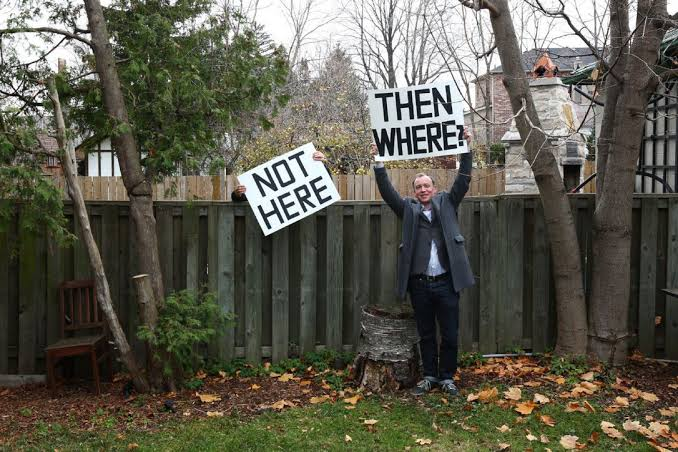

Source: [NYT Op-ed on Afforadable Housing, May 2026](https://www.nytimes.com/interactive/2026/05/18/opinion/affordable-housing-america.html)

<h4>So let's take a look at what people are saying about housing in our data</h4>

In [ ]:
# --- Keyword based search ---
HOUSING_KEYWORDS = [
    r"\bhousing\b",
    r"\baffordable housing\b",
    r"\brent\b",
    r"\blandlord\b",
    r"\btenant\b",
    r"\bzoning\b",
    r"\bdensity\b",
    r"\bapartment\b",
    r"\bstudio\b",
    r"\bshelter\b",
    r"\bhomeless\b",
    r"\bmulti[- ]family\b",
]
HOUSING_RE = re.compile("|".join(HOUSING_KEYWORDS), flags=re.IGNORECASE)

def is_about_housing(text: str) -> bool:
    """Similar housing keyword search
    """
    if not isinstance(text, str) or not text.strip():
        return False
    return HOUSING_RE.search(text) is not None


public["about_housing_keywords"] = public["utterance"].map(is_about_housing)
housing = public[(public["about_housing_keywords"])& (public['is_public_comment']==True)].copy()
print(f"Housing-topic public remarks (keyword stand-in): {len(housing):,}")


In [ ]:
public['is_public_comment'].sum()

Now we are going to use an existing Zero-shot stance detector to look at attitudes around housing.

We've actually run this stance detector already, and will load the data in a minute, but for now let's run some examples in case you want to try other statements.

We'll use this model: [`NLP-Debater-Project/debertav3-stance-detection`](https://huggingface.co/NLP-Debater-Project/debertav3-stance-detection)


The model takes a particular arugment and text and predicts if this text is for or against the argument.

```text
Topic: {topic} [SEP] Argument: {argument}
```

Labels: **PRO** (supports topic) vs **CON** (opposes).

We score **PC remarks** only (already filtered above).

In [ ]:
##Stance model

import torch
from transformers import AutoModelForSequenceClassification, AutoTokenizer

STANCE_MODEL = "NLP-Debater-Project/debertav3-stance-detection"
MAX_PER_CITY = 40  # raise for fuller estimates
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

tokenizer = AutoTokenizer.from_pretrained(STANCE_MODEL)
stance_model = AutoModelForSequenceClassification.from_pretrained(STANCE_MODEL)
stance_model.to(DEVICE)
stance_model.eval()
print("device:", DEVICE)


@torch.no_grad()
def predict_stance(argument: str,topic: str) -> tuple[str, float]:
    text = f"Topic: {topic} [SEP] Argument: {argument}"
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=512)
    inputs = {k: v.to(DEVICE) for k, v in inputs.items()}
    logits = stance_model(**inputs).logits
    probs = torch.softmax(logits, dim=-1)[0]
    pred = int(torch.argmax(probs).item())
    label = "PRO" if pred == 1 else "CON"
    return label, float(probs[pred].item())


Now we are going to create a DataFrame to keep track of the stance and stance confidence.



In [ ]:
print(housing.shape)
small = housing.sample(20)
print(small.shape)

In [ ]:
##this is the topic we want to see if comments agree or disagree with
topic = "We urgently need more affordable apartments for working families."

In [ ]:
not_housing_test

In [ ]:
not_housings_test = public.loc[22264]['utterance']
not_housings_test

In [ ]:
##if you want to sample

#not_housing_test = public[(public["about_housing"]==False) \
#                         & (public["utterance"].str.split().map(len)>15)\
#                         &(public["is_public_comment"]==True)]["utterance"].sample(1)
#not_housing_test.values[0]

In [ ]:
housing_test = public.loc[4751]['utterance']

In [ ]:
#if you want to sample
#housing_test = public[(public["about_housing"]==True) \
#                          & (public["utterance"].str.split().map(len)>15)\
#                          &(public["is_public_comment"]==True)]["utterance"].sample(1)
#housing_test

In [ ]:
housing_test

In [ ]:
predict_stance(not_housing_test,topic=topic)

In [ ]:
predict_stance(housing_test,topic=topic)

In [ ]:
predict_stance("the best kind of home is a single family home even if very few people can afford one ",topic=topic)

In [ ]:

x = small["utterance"].apply(predict_stance,topic=topic)
small["density_stance"] = [i[0] for i in x]
small["density_stance_conf"] = [i[1] for i in x]
small["density_stance"].value_counts()

In [ ]:
pd.set_option('display.max_colwidth', None)
small[small["density_stance"]=="PRO"]["utterance"]

<h3>Now we are going to load in data where we've precomputed the stance on comments about housing</h3>

You can find the data here: [Stance data](https://drive.google.com/file/d/1Jg6BeaB79alftkFeOM9KrLG16cxRSo2K/view?usp=sharing)

In [ ]:
stance = pd.read_csv("utterance_predictions.csv", dtype={"fips": str})
stance.columns

In [ ]:
combined_data = public.merge(stance,left_index=True,right_index=True)
combined_data.shape[0]==public.shape[0]==stance.shape[0]
combined_data.columns

<h4>Let's take a look at the fraction of comments about housing and how many of those are pro more affordable housing across the cities</h4>

In [ ]:
housing_by_city = combined_data[combined_data["is_public_comment"]==True].groupby("city")["about_housing"].mean()
ax = housing_by_city.plot( marker="o",
    linestyle="None")
ax.set_xticks(range(len(housing_by_city)))
ax.set_xticklabels(
    housing_by_city.index,
    rotation=45,
    ha="right",
)

In [ ]:
pro_housing = combined_data[(combined_data["is_public_comment"]==True) & \
 (combined_data["about_housing"]>=.5)]

pro_housing['housing_stance']=pro_housing['housing_stance']\
.map({"PRO":True,"CON":False})

pro_housing = pro_housing.groupby("city")["housing_stance"].mean()
ax = pro_housing.plot( marker="o",
    linestyle="None")
ax.set_xticks(range(len(pro_housing)))
ax.set_xticklabels(
    pro_housing.index,
    rotation=45,
    ha="right",
)



<h4>Fun things to try:</h4>



*   Look at pro-housing stance with many different statements
*   Compare to statistics about the city like income and existing housing density
*   Build a supervised classifier that does a better job!

<h4>Some more data for you to explore</h4>

[Vote records 2024](https://drive.google.com/file/d/1eweHkqEcqS13jOFaSPY5qcChwM7kdXm0/view?usp=sharing)

[Socioeconomic data](https://drive.google.com/file/d/1a9sJn9B9phNvOmZy0lYE3P3PbiAnnziK/view?usp=sharing)

[Metadata](https://drive.google.com/file/d/1AwRoIQxKGHVOPTKvm3fF2vfJIakSmFks/view?usp=sharing)

Make sure you read the FIPS in as a string like below.

In [ ]:
demos = pd.read_csv("city_socioeconomic_metadata.csv",dtype={"fips": str})
votes = pd.read_csv("city_presidential_vote_2024.csv",dtype={"fips": str})
metadata = pd.read_csv("metadata.csv",dtype={"fips": str})

In [ ]:
import matplotlib as plt

In [ ]:
fips_lookup = {v:f for v,f in zip(metadata['video_id'],metadata['fips'])}
i_to_f = {i:fips_lookup[v] for i,v in zip(public.index,public['video_id'])}
stance['fips'] = stance.index.map(i_to_f)

In [ ]:
v = votes.groupby('city')['rep_two_party_share'].max().loc[list(set(public['city']))]
pd.concat((pro_housing,v),axis=1)

<h4>Now let's take a look at what the mayor has to say, and compare their position about housing and look at the two cities where we have the most comments, Seattle and Ann Arbor</h4>

We won't be able to look at the transcript data for Seattle, as the mayor doesn't attend meetings. But we'll return to Seattle in a minute.

In [ ]:
public_pro_housing_a2 = (combined_data[(combined_data["is_public_comment"]==True) & \
 (combined_data["about_housing_y"]>=.5) & \
  (combined_data["city"]=="ANN ARBOR")& \
   (combined_data["housing_stance_conf"]>.9)]["housing_stance"]=='PRO').mean()
mayor_pro_housing_a2 = (combined_data[(combined_data["is_mayor_speaking"]==True) & \
 (combined_data["about_housing_y"]>=.4)& \
  (combined_data["city"]=="ANN ARBOR")& \
   (combined_data["housing_stance_conf"]>.9)]["housing_stance"]=='PRO').mean()
print(public_pro_housing_a2 )
print(mayor_pro_housing_a2)

In [ ]:
pd.set_option('display.max_colwidth', None)
combined_data[(combined_data["is_mayor_speaking"]==True) & \
 (combined_data["about_housing_y"]>=.8)& \
  (combined_data["city"]=="ANN ARBOR") & \
   (combined_data["housing_stance_conf"]>.95)]["utterance"]

In [ ]:
import requests
from bs4 import BeautifulSoup

<h3>Campaign pages</h3>

As we can see the mayors don't necessarily make a lot of substantive statements in council. Another source of information for their opinions on issues is their campaign pages. So let's look at the sites for the Ann Arbor and Seattle mayors.

We can also take a look at the campaign pages of the mayors.

Ann Arbor [Chris Taylor](https://www.taylorforannarbor.com/)



In [ ]:
#First let's get Ann Arbor
r= requests.get("https://www.taylorforannarbor.com/the-mayors-record")
soup = BeautifulSoup(r.content, "html.parser")

#code modified from GPT
housing_heading = soup.find(
    lambda tag: (
        tag.name in {"h2", "h3", "h4", "h5"}
        and "housing" in tag.get_text(" ", strip=True).lower()
    )
)
print("Heading:", housing_heading.get_text(" ", strip=True))
# The heading is contained in a parent <li>, which also contains
# the nested list of housing accomplishments.
housing_section = housing_heading.find_parent("li")

housing_list = housing_section.find(["ul", "ol"]) if housing_section else None

if housing_list is None:
    raise RuntimeError("Housing bullet list not found.")

housing_items_ann_arbor = [
    item.get_text(" ", strip=True)
    for item in housing_list.find_all("li", recursive=False)
]



In [ ]:
taylor_housing_claims = pd.DataFrame({'statement':housing_items_ann_arbor,'mayor':['A2' for i in range(len((housing_items_ann_arbor)))] })

In [ ]:

x = taylor_housing_claims['statement'].apply(predict_stance,topic=topic)
taylor_housing_claims["housing_stance"]=[i[0] for i in x.values]
taylor_housing_claims["housing_stance_conf"]=[i[1] for i in x.values]

In [ ]:
taylor_housing_claims

<h4>Now let's grab data from Bruce Harrell, the Seattle mayor at the time of our data 2024-2025</h4>

This can be found on his campaign page [Bruce Harrell](https://www.bruceforseattle.com/one-seattle/)

In [ ]:
r= requests.get("https://www.bruceforseattle.com/one-seattle/")
soup = BeautifulSoup(r.content, "html.parser")
policy_text = soup.find("main").get_text("\n", strip=True)


In [ ]:
x = predict_stance(policy_text,topic=topic)
harrell_housing_claims = pd.DataFrame({"housing_stance":[x[0]],"housing_stance_conf":[x[1]],\
                          "statement":[policy_text],'mayor':['Harrell']})

In [ ]:
x

<h4>Seattle's mayor was recently defeated by a more progressive candidate, Katie Wilson. Let's take a look at her housing claims</h4>

These come from her campaign page: [Katie Wilson](https://www.wilsonforseattle.com/housing)

In [ ]:
wilson_claims = [


"The cost to rent or buy a home in Seattle is far too high. Too many families are paying well over a third of their income in housing costs, or leaving the city altogether. That leaves people with long, polluting commutes, and drives down enrollment at our schools. High rents also mean rising homelessness. We can’t continue to accept inaction from our elected leaders.",



"I have a proven record of winning major victories on affordable housing and renters’ rights. In 2018, when the county proposed using public funds to upgrade the billionaire-owned Mariners’ stadium, I fought to shift millions of dollars to housing instead.",



"In 2020, I led on designing and passing JumpStart Seattle, our city’s landmark tax on wealthy corporations, with the revenue dedicated above all to housing — until last year, when our current mayor Bruce Harrell diverted the bulk of those funds to plug a budget hole, because he didn’t want to anger his rich friends by raising new progressive revenue." ,



"And starting in 2021, I coordinated the Stay Housed Stay Healthy coalition, winning stronger protections for renters in Seattle and seven other jurisdictions across King County, from longer notice of rent increases to caps on move-in fees and late fees.",



"When I moved to Seattle in my early 20s, my husband and I were able to find an affordable home to rent while we built a life here, even though we didn’t have high-paying jobs lined up or savings in the bank. Today, it would be nearly impossible for another young couple to follow in our footsteps. Let’s make sure that our parents, our neighbors, and our children can afford to continue calling Seattle home."
]
wilson_housing_claims = pd.DataFrame({'statement':wilson_claims,'mayor':['Wilson' for i in range(len((wilson_claims)))] })

In [ ]:
x = wilson_housing_claims['statement'].apply(predict_stance,topic=topic)
wilson_housing_claims["housing_stance"]=[i[0] for i in x]
wilson_housing_claims["housing_stance_conf"]=[i[1] for i in x]



In [ ]:
mayor_claims = pd.concat((taylor_housing_claims,wilson_housing_claims,\
                          harrell_housing_claims))
print(mayor_claims["housing_stance"].value_counts())
mayor_claims.groupby('mayor')["housing_stance_conf"].mean()

<h4>Fun things to try:</h4>



*   Extract only Harrell's sentences about housing and repeat
*   Scrape data for Yousef Rabhi [running for mayor in Ann Arbor](https://www.voteyousef.com/) - also claims to be more progressive than incumbent



<h3>Discussion</h3>

Really difficult to know local officials' actual stance. Many statements in meetings are procedural. Campaign materials are incredibly sparse.

What would you do to get a better understanding of their position on key issues?

<h3>Let's take a look at crime</h3>

Here we used the topic ``this city needs to be tough on crime''

In [ ]:
tough_on_crime = combined_data[(combined_data["is_public_comment"]==True) & \
 (combined_data["about_crime"]>=.5)]

tough_on_crime['crime_stance']=tough_on_crime['crime_stance']\
.map({"PRO":True,"CON":False})

tough_on_crime = tough_on_crime.groupby("city")["crime_stance"].mean()
ax = tough_on_crime.plot( marker="o",
    linestyle="None")
ax.set_xticks(range(len(tough_on_crime)))
ax.set_xticklabels(
    tough_on_crime.index,
    rotation=45,
    ha="right",
)


<h3>Discussion</h3>

Not a lot of data but, do you think any thing is going on here? Where do you see tougher on crime attitudes?

You can load in these datasets and explore more.

<h3>Now we'll take a look at gender dynamics amongst city council officials</h3>



*   Women are more likely to be interrupted in congress (Miller and Sutherland 2023)
*   Women joining a committee lead to fewer interruptions and more on topic conversations (Ban et al. 2022)
*   At a local level there is a LOT we don't know. At at very basic level we know that there is a gender gap in terms of simple representation - only ~20\% of all mayors in cities with at least 30,000 people are women (Holman 2017)

There are a lot of open questions for you to explore. But to give a taster ...


we've put together a [small gender dataset](https://drive.google.com/file/d/1gHLgqaLNSIFnTMfTWyvAi9j_QRsR2cWk/view?usp=sharing)

*   Who speaks more frequently?
*   Who has longer utterances?

References:




Miller, Michael G., and Joseph L. Sutherland. "The effect of gender on interruptions at congressional hearings." American Political Science Review 117.1 (2023): 103-121.

Ban P, Grimmer J, Kaslovsky J, West E (2022), "How Does the Rising Number of Women in the U.S. Congress Change Deliberation? Evidence from House Committee Hearings". Quarterly Journal of Political Science, Vol. 17 No. 3 pp. 355–387, doi: https://doi.org/10.1561/100.00020112

Holman, Mirya R. "Women in local government: What we know and where we go from here." State and Local Government Review 49.4 (2017): 285-296.

In [ ]:

gender = pd.read_csv("utterances_gender.csv", dtype={"fips": str})

In [ ]:

gender.gender.value_counts()

In [ ]:
def get_utterance_length(utt):
  return len(utt.split())
gender['u_length']= gender['utterance'].apply(get_utterance_length)

In [ ]:
gender.groupby('gender')['u_length'].mean()

<h3>Let's take a look at the stats per city</h3>

In [ ]:
def get_speaking_gap(city_df):
  ulens = city_df.groupby('gender')['u_length'].mean()
  utts = city_df['gender'].value_counts()
  if 'Female' in ulens.index and 'Male' in ulens.index:
    return utts['Male']*ulens['Male']-utts['Female']*ulens['Female']
  else:
    print(ulens)

In [ ]:
city_gaps = gender.groupby('city').apply(get_speaking_gap)
ax = city_gaps.plot( marker="o",
    linestyle="None")
ax.set_xticks(range(len(city_gaps)))
ax.set_xticklabels(
    city_gaps.index,
    rotation=45,
    ha="right",
)

<h3>Discussion</h3>

What would you look at next? What are your questions about gender in local government?

How would you look at interruptions in city council discussions?